# HW1: Поиск информативного скрытого слоя в LLMs

Исследование информативности слоев DistilBERT для задачи sentiment classification


In [1]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cpu


## 1. Загрузка модели и данных


In [3]:
# Модель: DistilBERT (6 слоев)
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_hidden_states=True).to(device)
model.eval()

print(f'Модель загружена: {model_name}')
print(f'Количество слоев: {model.config.n_layers}')


Модель загружена: distilbert-base-uncased
Количество слоев: 6


In [ ]:
# Датасет: IMDB sentiment (сбалансированная выборка)
# Берем 500 negative (0-499) + 500 positive (12500-12999)
dataset = load_dataset('imdb', split='train')
test_dataset = load_dataset('imdb', split='test')

train_idx = list(range(500)) + list(range(12500, 13000))
test_idx = list(range(250)) + list(range(12500, 12750))

train_texts = [dataset['text'][i] for i in train_idx]
train_labels = np.array([dataset['label'][i] for i in train_idx])
test_texts = [test_dataset['text'][i] for i in test_idx]
test_labels = np.array([test_dataset['label'][i] for i in test_idx])

print(f'Train: {len(train_texts)}, Test: {len(test_texts)}')
print(f'Train labels distribution: {np.bincount(train_labels)}')
print(f'Test labels distribution: {np.bincount(test_labels)}')


Train: 1000, Test: 500
Train labels distribution: [500 500]
Test labels distribution: [250 250]


## 2. Извлечение представлений из слоев


In [5]:
def extract_layer_embeddings(texts, layer_idx, max_length=256):
    """Извлечение CLS-токена из заданного слоя"""
    embeddings = []
    
    with torch.no_grad():
        for text in tqdm(texts, desc=f'Layer {layer_idx}'):
            inputs = tokenizer(text, return_tensors='pt', 
                             truncation=True, max_length=max_length, 
                             padding='max_length').to(device)
            outputs = model(**inputs)
            
            # hidden_states: (n_layers+1, batch, seq_len, hidden_dim)
            # Берем CLS токен [0] из нужного слоя
            hidden_state = outputs.hidden_states[layer_idx][0, 0, :].cpu().numpy()
            embeddings.append(hidden_state)
    
    return np.array(embeddings)


In [6]:
# Извлекаем представления для всех слоев (0 = embedding, 1-6 = transformer layers)
n_layers = model.config.n_layers + 1  # +1 для embedding layer

train_embeddings = {}
test_embeddings = {}

for layer_idx in range(n_layers):
    print(f'\nИзвлечение слоя {layer_idx}...')
    train_embeddings[layer_idx] = extract_layer_embeddings(train_texts, layer_idx)
    test_embeddings[layer_idx] = extract_layer_embeddings(test_texts, layer_idx)



Извлечение слоя 0...


Layer 0: 100%|██████████| 500/500 [00:18<00:00, 26.95it/s]



Извлечение слоя 1...


Layer 1: 100%|██████████| 500/500 [00:18<00:00, 26.68it/s]



Извлечение слоя 2...


...

Layer 4: 100%|██████████| 500/500 [00:19<00:00, 26.26it/s]



Извлечение слоя 5...


Layer 5: 100%|██████████| 500/500 [00:17<00:00, 28.00it/s]



Извлечение слоя 6...


Layer 6: 100%|██████████| 500/500 [00:17<00:00, 28.31it/s]


## 3. Обучение классификаторов на каждом слое


In [7]:
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

In [8]:
results = []

for layer_idx in range(n_layers):
    print(f'\nСлой {layer_idx}...')
    
    X_train = train_embeddings[layer_idx]
    X_test = test_embeddings[layer_idx]
    
    # Простой линейный классификатор
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, train_labels)
    
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)
    
    train_acc = accuracy_score(train_labels, train_pred)
    test_acc = accuracy_score(test_labels, test_pred)
    test_f1 = f1_score(test_labels, test_pred)
    
    results.append({
        'layer': layer_idx,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'test_f1': test_f1
    })
    
    print(f'Train Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}, F1: {test_f1:.3f}')



Слой 0...
Train Acc: 0.500, Test Acc: 0.500, F1: 0.000

Слой 1...
Train Acc: 0.741, Test Acc: 0.712, F1: 0.699

Слой 2...
Train Acc: 0.811, Test Acc: 0.770, F1: 0.761

Слой 3...
Train Acc: 0.888, Test Acc: 0.758, F1: 0.740

Слой 4...
Train Acc: 0.880, Test Acc: 0.746, F1: 0.734

Слой 5...
Train Acc: 0.943, Test Acc: 0.744, F1: 0.731

Слой 6...
Train Acc: 0.930, Test Acc: 0.832, F1: 0.820


## 4. Результаты и визуализация


In [9]:
import pandas as pd

df_results = pd.DataFrame(results)
print('\nРезультаты по слоям:')
print(df_results.to_string(index=False))

top3 = df_results.nlargest(3, 'test_acc')
print('\nТоп-3 лучших слоя:')
print(top3.to_string(index=False))



Результаты по слоям:
 layer  train_acc  test_acc  test_f1
     0      0.500     0.500 0.000000
     1      0.741     0.712 0.698745
     2      0.811     0.770 0.760915
     3      0.888     0.758 0.739785
     4      0.880     0.746 0.733753
     5      0.943     0.744 0.731092
     6      0.930     0.832 0.819742

Топ-3 лучших слоя:
 layer  train_acc  test_acc  test_f1
     6      0.930     0.832 0.819742
     2      0.811     0.770 0.760915
     3      0.888     0.758 0.739785


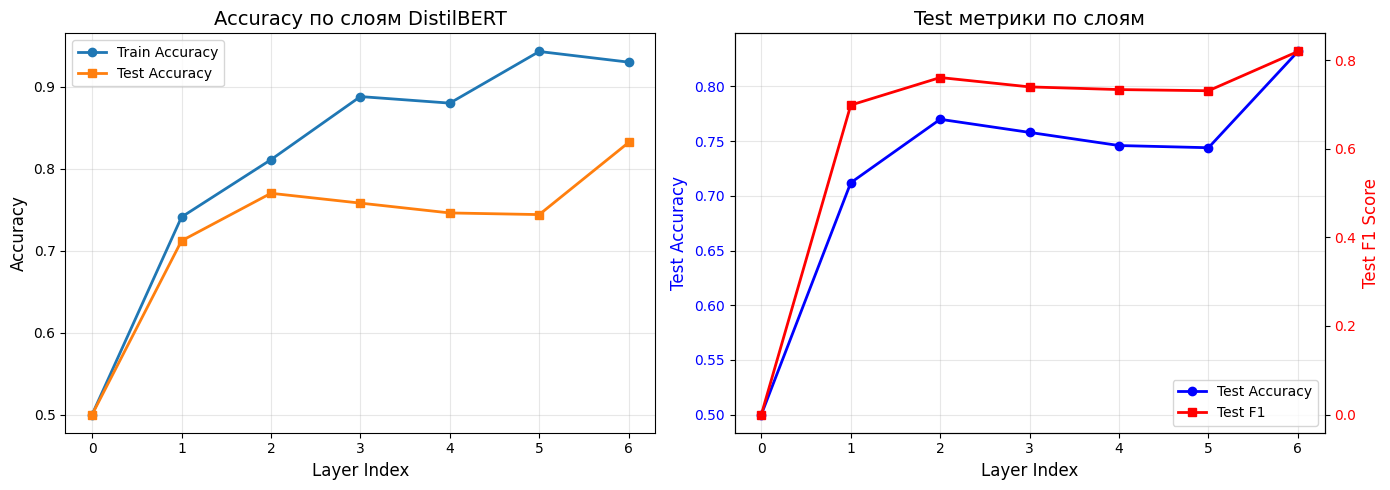


График сохранен: layer_analysis.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_results['layer'], df_results['train_acc'], 
             marker='o', label='Train Accuracy', linewidth=2)
axes[0].plot(df_results['layer'], df_results['test_acc'], 
             marker='s', label='Test Accuracy', linewidth=2)
axes[0].set_xlabel('Layer Index', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy по слоям DistilBERT', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(n_layers))

ax2 = axes[1]
ax2.plot(df_results['layer'], df_results['test_acc'], 
         marker='o', label='Test Accuracy', linewidth=2, color='blue')
ax2.set_xlabel('Layer Index', fontsize=12)
ax2.set_ylabel('Test Accuracy', fontsize=12, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_xticks(range(n_layers))

ax2_twin = ax2.twinx()
ax2_twin.plot(df_results['layer'], df_results['test_f1'], 
              marker='s', label='Test F1', linewidth=2, color='red')
ax2_twin.set_ylabel('Test F1 Score', fontsize=12, color='red')
ax2_twin.tick_params(axis='y', labelcolor='red')

ax2.set_title('Test метрики по слоям', fontsize=14)
ax2.grid(True, alpha=0.3)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.savefig('layer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nГрафик сохранен: layer_analysis.png')


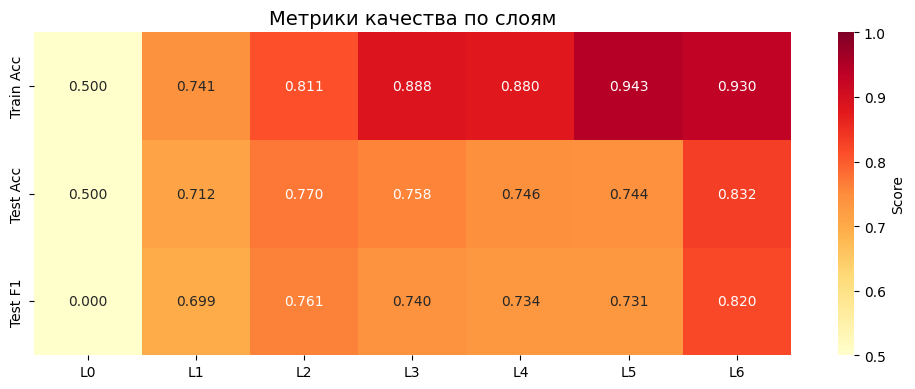

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

metrics_matrix = df_results[['train_acc', 'test_acc', 'test_f1']].T
metrics_matrix.columns = [f'L{i}' for i in range(n_layers)]
metrics_matrix.index = ['Train Acc', 'Test Acc', 'Test F1']

sns.heatmap(metrics_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Score'}, ax=ax, vmin=0.5, vmax=1.0)
ax.set_title('Метрики качества по слоям', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Выводы


1. Лучший слой: 6
   Test Accuracy: 0.832
   Test F1: 0.820

2. Худший слой: 0
   Test Accuracy: 0.500

3. Средняя accuracy по группам слоев:
   Начальные слои (0-2): 0.661
   Средние слои (3-5): 0.749
   Финальные слои (6): 0.832

4. Основные наблюдения:
   - Финальные слои лучше, модель использует всю глубину

5. Рекомендация:
   Для sentiment analysis на DistilBERT использовать слой 6